## Model: XGBoost

## Setup

Load the libraries needed for preprocessing, model tuning, evaluation, and plotting. This cell also sets the project root so the notebook can be run from the notebook folder or the repository root.

In [4]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

import evaluate
import utils
importlib.reload(evaluate)
importlib.reload(utils)

from evaluate import evaluate_model, save_metrics
from utils import save_model

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Load Processed Data

Load the prepared train/test files and rebuild the target split. This keeps the notebook compatible with both the combined `train.csv` / `test.csv` format and the separated `X_*.csv` / `y_*.csv` format.

In [5]:
PROCESSED_DIR = ROOT / "data" / "processed"


def load_processed_data(processed_dir: Path = PROCESSED_DIR):
    """Load the prepared train/test data used by the model notebook."""
    combined_train_path = processed_dir / "train.csv"
    combined_test_path = processed_dir / "test.csv"

    if combined_train_path.exists() and combined_test_path.exists():
        train_df = pd.read_csv(combined_train_path)
        test_df = pd.read_csv(combined_test_path)
        target_column = "price" if "price" in train_df.columns else train_df.columns[-1]
        return train_df, test_df, target_column

    x_train = pd.read_csv(processed_dir / "X_train.csv")
    x_test = pd.read_csv(processed_dir / "X_test.csv")
    y_train = pd.read_csv(processed_dir / "y_train.csv")
    y_test = pd.read_csv(processed_dir / "y_test.csv")

    target_column = y_train.columns[0]
    train_df = pd.concat([x_train, y_train], axis=1)
    test_df = pd.concat([x_test, y_test], axis=1)
    return train_df, test_df, target_column


train_df, test_df, target_column = load_processed_data()
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

print(f"Training features: {X_train.shape}")
print(f"Testing features : {X_test.shape}")
print(f"Training target  : {y_train.shape}")
print(f"Testing target   : {y_test.shape}")
train_df.head()


Training features: (8000, 61)
Testing features : (2000, 61)
Training target  : (8000,)
Testing target   : (2000,)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,price
0,0.857356,0.756125,-0.968378,0.145933,0.725482,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,7700
1,1.550225,-0.808460,2.382821,-1.899858,-1.642795,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,9500
2,-1.221251,-0.213110,-0.298138,0.145933,-0.853369,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,8400
3,-1.221251,0.235999,-0.968378,0.145933,0.725482,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,7400
4,1.550225,1.533634,2.382821,-1.899858,-1.642795,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10000


## Tune XGBoost

Search a wider set of XGBoost hyperparameters so the model can capture nonlinear patterns better while still controlling overfitting.

In [6]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [column for column in X_train.columns if column not in categorical_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

transformers = []
if numeric_features:
    transformers.append(("num", numeric_transformer, numeric_features))
if categorical_features:
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
                verbosity=0
            )
        )
    ]
)

param_distributions = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__n_estimators": [200, 300, 400, 500],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [1.0, 1.5, 2.0, 3.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print(f"Best CV RMSE: {-random_search.best_score_:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'model__subsample': 0.8, 'model__reg_lambda': 3.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 400, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
Best CV RMSE: 1.2929


## Evaluate

Measure how the tuned model performs on the held-out test set and convert the predictions into a metrics table.

In [7]:
y_pred = best_model.predict(X_test)

metrics = evaluate_model(y_test, y_pred, "XGBoost")
save_metrics(metrics)

pd.DataFrame([metrics])


,model_name,mse,rmse,mae,r2
0,XGBoost,0.397674,0.630614,0.227472,1.0


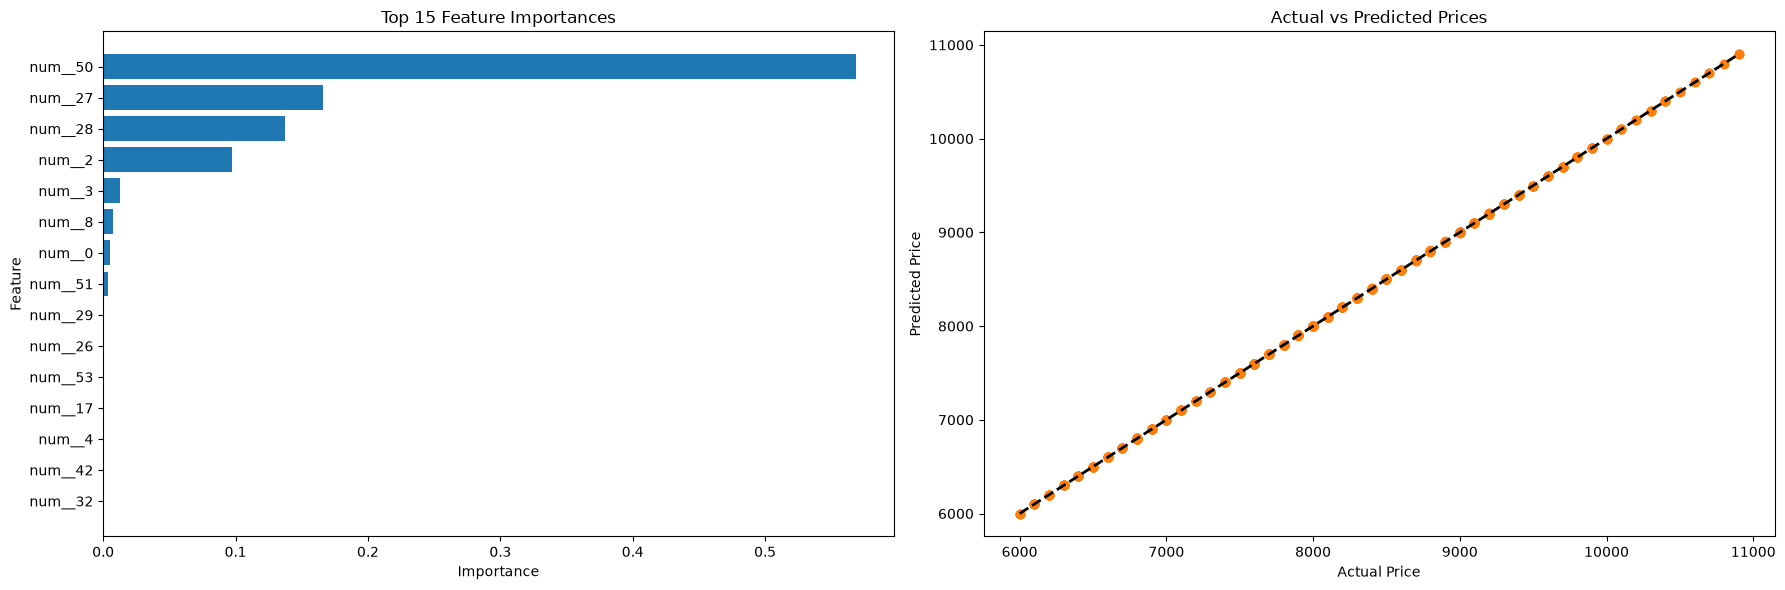

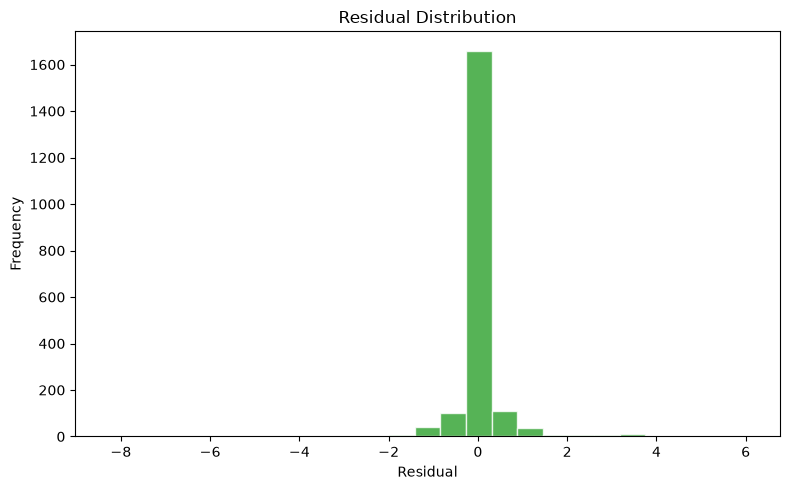

In [8]:
# Plot the most important transformed features and compare actual vs predicted prices.
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
feature_importances = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importances
    })
    .sort_values("importance", ascending=False)
    .head(15)
    .sort_values("importance", ascending=True)
 )

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].barh(importance_df["feature"], importance_df["importance"], color="#1f77b4")
axes[0].set_title("Top 15 Feature Importances")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

axes[1].scatter(y_test, y_pred, alpha=0.7, color="#ff7f0e")
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
axes[1].plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black", linewidth=2)
axes[1].set_title("Actual vs Predicted Prices")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=25, color="#2ca02c", alpha=0.8, edgecolor="white")
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


## Save Model

Persist the tuned pipeline so the same preprocessing and XGBoost parameters can be reused later without retraining.

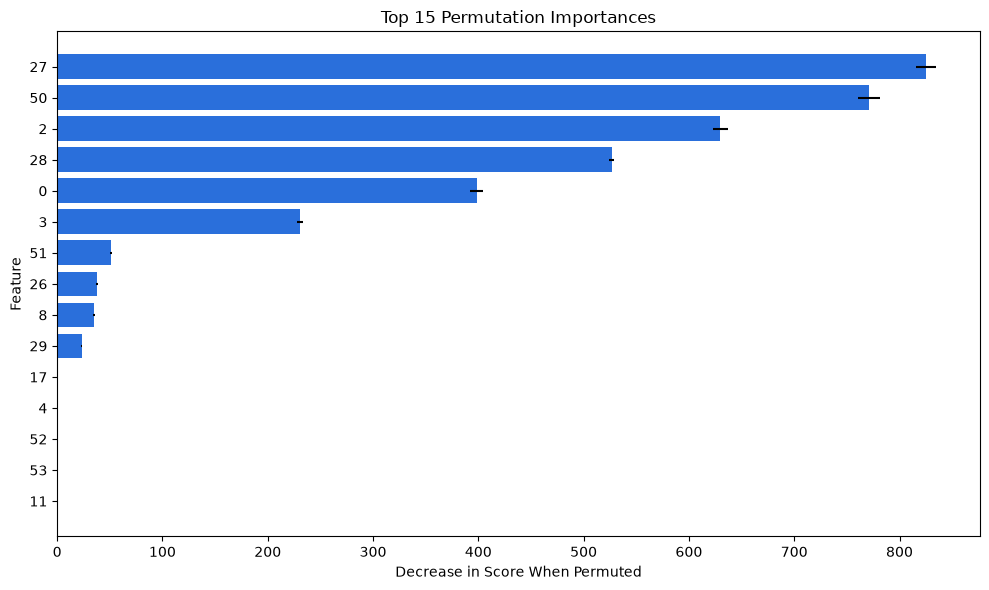

,feature,importance,std
11,11,0.033084,0.001896
53,53,0.042479,0.002803
52,52,0.070868,0.002995
4,4,0.719848,0.050528
17,17,0.948054,0.057765
29,29,23.387554,0.294927
8,8,35.096343,1.132506
26,26,37.785141,0.586581
51,51,50.970343,1.125016
3,3,230.568727,2.464598


In [9]:
# Measure permutation importance on the fitted pipeline.
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
 )

permutation_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(
    permutation_df["feature"],
    permutation_df["importance"],
    xerr=permutation_df["std"],
    color="#2a6fdb"
 )
plt.title("Top 15 Permutation Importances")
plt.xlabel("Decrease in Score When Permuted")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

permutation_df

In [14]:
# Extract best parameters and scores from random_search
best_params = random_search.best_params_
best_cv_rmse = -random_search.best_score_
test_rmse = metrics['rmse']

# Print values
print(f"RMSE on Test Data: ${test_rmse:.2f}")
print(f"Best CV RMSE:      {best_cv_rmse:.2f}")
print(f"max_depth:         {best_params.get('model__max_depth')}")
print(f"learning_rate:     {best_params.get('model__learning_rate')}")
print(f"n_estimators:      {best_params.get('model__n_estimators')}")

RMSE on Test Data: $0.63
Best CV RMSE:      1.29
max_depth:         8
learning_rate:     0.03
n_estimators:      400


## Explain Model Predictions

Use permutation importance to see which original features matter most to the tuned pipeline. This is a practical explainability step when SHAP is not available in the current environment.

In [11]:
MODEL_PATH = save_model(best_model, "xgboost")
MODEL_PATH


Saved model: ../models/xgboost.joblib


'../models/xgboost.joblib'